In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import gc
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback)

In [ ]:
df = pd.read_csv("FINAL_cleaned_annotations_RESOLVED1.csv")
df

,author,text,created_utc,post_id,source,cleaned_text,no_stopword_text,duo,text_length,annotator_1,annotator_2,annotator_3,annotator_4,final_sentiment
0,Special_Dinner3828,Hi there. The specific time I was saying Shuve...,11/06/2025 10:15,1l8jznl,comment,hi there the specific time i was saying shuvee...,hi specific time saying shuvee protecting az f...,AzVer,581,neutral,negative,neutral,NaN,neutral
1,Dependent_Factor5975,May point si ashley ang yun yung dapat intindi...,19/06/2025 2:11,1le4nli,comment,may point si ashley ang yun yung dapat intindi...,point ashley yun yung dapat intindihin fans az,AzVer,67,neutral,negative,neutral,NaN,neutral
2,blinkeu_theyan,"Dahil talaga kay Az, super naiinspire na ako t...",27/06/2025 15:12,1llvdl3,comment,dahil talaga kay az super naiinspire na ako to...,dahil talaga kay az super naiinspire always pr...,AzVer,82,positive,positive,positive,NaN,positive
3,tinayr,dagdag ko lang din na sobrang sipag ng mga adm...,14/06/2025 16:03,1lbbjit,comment,dagdag ko lang din na sobrang sipag ng mga adm...,dagdag ko lang din sobrang sipag admins magliv...,AzVer,113,positive,positive,positive,NaN,positive
4,pumpkinmuffin_09,"idk rin talaga, same reason pa rin hate sakani...",29/06/2025 3:21,1lmppx9,comment,idk rin talaga same reason pa rin hate sakanil...,idk talaga reason hate sakanila dahil 3pts nom...,AzVer,252,negative,neutral,negative,NaN,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8043,Ok-Outcome-4189,Ang worry ko lang now ay mukang magkaka-taping...,03/07/2025 4:37,1lpx6wf,comment,ang worry ko lang now ay mukang magkakataping ...,worry ko lang mukang magkakataping friends par...,RaWi,188,negative,negative,neutral,NaN,negative
8044,StatusCelery1293,Kung nakikita mo lang andaming sponsors ang na...,02/07/2025 13:45,1lpv7k1,comment,kung nakikita mo lang andaming sponsors ang na...,kung nakikita mo lang andaming sponsors natrig...,RaWi,414,negative,negative,positive,NaN,negative
8045,btssanscontext,RaWi ang big winner ko! maybe standout is the ...,30/06/2025 18:55,1lo4g4i,comment,rawi ang big winner ko maybe standout is the w...,rawi big winner ko maybe standout wrong term k...,RaWi,392,positive,negative,neutral,positive,positive
8046,Signal_Preference247,"Kapamilya: Ralph, ate Klang, Emilio\n\n\nKapus...",30/06/2025 13:06,1lo4g4i,comment,kapamilya ralph ate klang emilio kapuso az wil...,kapamilya ralph ate klang emilio kapuso az mic...,RaWi,55,neutral,negative,neutral,NaN,neutral


In [ ]:
texts = df["cleaned_text"].astype(str)
labels = df["final_sentiment"]

le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [ ]:
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2,
    random_state=42, stratify=train_labels_full
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512
    )

train_encodings = tokenize(train_texts)
val_encodings   = tokenize(val_texts)
test_encodings  = tokenize(test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset   = SentimentDataset(val_encodings, val_labels)
test_dataset  = SentimentDataset(test_encodings, test_labels)

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
def run_experiment(batch_size, lr, epochs=4):
    print(f"\nRunning mBERT | batch={batch_size} | lr={lr}")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-multilingual-cased",
        num_labels=num_labels)

In [ ]:
def run_experiment(batch_size, lr, epochs=4):

    print(f"\nRunning mBERT | batch={batch_size} | lr={lr}")

    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-multilingual-cased",
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f"./mbert_bs{batch_size}_lr{lr}",

        eval_strategy="epoch",
        save_strategy="epoch",

        num_train_epochs=epochs,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        learning_rate=lr,
        weight_decay=0.1,

        warmup_ratio=0.1,
        lr_scheduler_type="linear",
        max_grad_norm=1.0,

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        logging_steps=50,
        fp16=torch.cuda.is_available(),
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    metrics = trainer.evaluate()

    f1 = metrics["eval_f1"]
    loss = metrics["eval_loss"]

    print(f"Validation F1 = {f1:.4f}")

    del trainer
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return f1, loss

In [ ]:
batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]

best_f1 = 0
best_params = None

for bs in batch_sizes:
    for lr in learning_rates:
        f1, loss = run_experiment(bs, lr, epochs=4)

        if f1 > best_f1:
            best_f1 = f1
            best_params = (bs, lr)

print("\nBEST CONFIG:", best_params, "F1:", round(best_f1, 4))


Running mBERT | batch=16 | lr=2e-05


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.554759,0.484541,0.807453,0.806215
2,0.369305,0.414559,0.857143,0.858011
3,0.225275,0.479875,0.855590,0.855617
4,0.203664,0.475303,0.861801,0.862209


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Validation F1 = 0.8604

BEST CONFIG: (16, 5e-05) F1: 0.8846


In [ ]:
best_bs, best_lr = best_params

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir="./best_mbert_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    num_train_epochs=4,

    per_device_train_batch_size=best_bs,
    per_device_eval_batch_size=best_bs,

    learning_rate=best_lr,
    weight_decay=0.1,

    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    max_grad_norm=1.0,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.522354,0.808230,0.805945
2,0.648556,0.412415,0.851708,0.853750
3,0.648556,0.491036,0.857143,0.858027
4,0.291053,0.424470,0.884317,0.885076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1288, training_loss=0.40075199944632395, metrics={'train_runtime': 742.1636, 'train_samples_per_second': 27.757, 'train_steps_per_second': 1.735, 'total_flos': 5420136405196800.0, 'train_loss': 0.40075199944632395, 'epoch': 4.0})

In [ ]:
pred_test = trainer.predict(test_dataset)
preds_test = np.argmax(pred_test.predictions, axis=1)

print(classification_report(test_labels, preds_test, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.92      0.78      0.84       489
     neutral       0.73      0.95      0.83       564
    positive       0.99      0.82      0.89       557

    accuracy                           0.85      1610
   macro avg       0.88      0.85      0.85      1610
weighted avg       0.88      0.85      0.86      1610



In [ ]:
test_df = df.iloc[test_texts.index].copy()
test_df["predicted_sentiment"] = le.inverse_transform(preds_test)

counts = (
    test_df
    .groupby(["duo", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)

In [ ]:
counts["score"] = (counts["positive"] - counts["negative"]) / \
                  (counts["positive"] + counts["negative"])

exp_scores = np.exp(counts["score"])
counts["percentage"] = exp_scores / exp_scores.sum() * 100

result = counts.sort_values("percentage", ascending=False)
print(result)

predicted_sentiment  negative  neutral  positive     score  percentage
duo                                                                   
RaWi                       21      244       154  0.760000   43.441068
BreKa                      85      151       162  0.311741   27.747511
CharEs                    133      144       141  0.029197   20.917839
AzVer                     178      192         5 -0.945355    7.893582


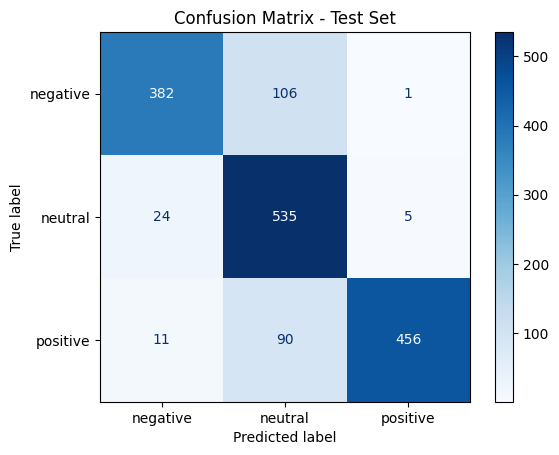

In [ ]:
cm = confusion_matrix(test_labels, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

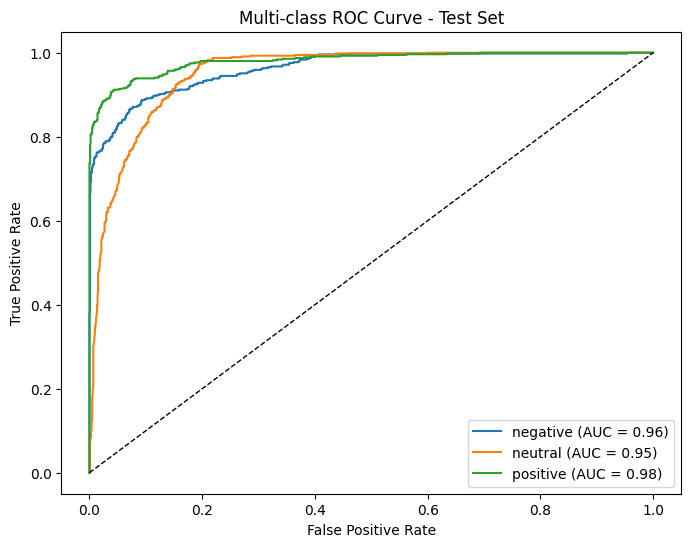

In [ ]:
y_test_bin = label_binarize(test_labels, classes=range(num_labels))
y_score = pred_test.predictions

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()